# **Finesse — Gamified Budgeting & Financial Health Scorer**

Anggota:
1. CFCC319D6Y0190 - Patrick Nicxon Hutabarat - Full-Stack Web Developer
2. CDCC319D6X0998 - Dame Theresia Rejeki Sidauruk - Data Science
3. CDCC319D6X1254 - Cikita Natasya Br Sembiring - Data Scientist
4. CACC319D6Y0343 - Rayza Indafri Yahya - AI Engineer
5. CACC319D6Y1720 - Samuel Gautama Manik - AI Engineer

# Exploratory Data Analysis (EDA) - Finesse Capstone Project
**Tujuan Analisis:** Tahapan Exploratory Data Analysis (EDA) ini dieksekusi terhadap dataset `finesse_dataset.csv` yang telah melalui tahap *preprocessing*.

Proses ini dibagi menjadi EDA(Univariat & Multivariat) untuk menemukan karakteristik dasar data, dilanjutkan dengan Targeted EDA untuk mengekstrak insight spesifik guna pengembangan fitur aplikasi Finesse.

## 1. Persiapan & Import Library
Langkah pertama adalah memuat pustaka-pustaka Python yang diperlukan untuk manipulasi data dan visualisasi grafik.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

In [ ]:
# Memuat dataset
drive.mount('/content/drive')
dataset_path = '/content/drive/MyDrive/Finesse_Project/finesse_dataset.csv'
df = pd.read_csv(dataset_path)

Mounted at /content/drive


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15239 entries, 0 to 15238
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_id          15239 non-null  object 
 1   user_id                 15239 non-null  object 
 2   date                    15239 non-null  object 
 3   amount                  15239 non-null  int64  
 4   category                15239 non-null  object 
 5   payment_method          15239 non-null  object 
 6   monthly_budget          15239 non-null  int64  
 7   cumulative_spend        15239 non-null  int64  
 8   financial_health_score  15239 non-null  float64
dtypes: float64(1), int64(3), object(5)
memory usage: 1.0+ MB


In [ ]:
df.describe()

,amount,monthly_budget,cumulative_spend,financial_health_score
count,1.523900e+04,1.523900e+04,1.523900e+04,15239.000000
mean,1.574139e+05,2.741331e+06,2.397614e+05,90.842577
std,3.318581e+05,6.766443e+05,4.289904e+05,16.254774
min,1.000000e+04,1.501000e+06,1.000000e+04,0.000000
25%,3.300000e+04,2.198000e+06,4.500000e+04,91.065000
50%,5.500000e+04,2.715000e+06,9.100000e+04,96.540000
75%,1.420000e+05,3.281000e+06,2.330000e+05,98.350000
max,2.493000e+06,3.997000e+06,5.091000e+06,99.750000


In [ ]:
df.head() #5 sampel data pertama

,transaction_id,user_id,date,amount,category,payment_method,monthly_budget,cumulative_spend,financial_health_score
0,TRANS033951,CUST00001,2023-03-14,179000,Hiburan & Nongkrong,Bank Transfer,1614000,179000,88.91
1,TRANS023682,CUST00001,2023-03-24,29000,Makan & Minum,Bank Transfer,1614000,208000,87.11
2,TRANS002749,CUST00001,2023-04-14,480000,Belanja Umum,Credit Card,1614000,480000,70.26
3,TRANS012804,CUST00001,2023-04-15,52000,Kebutuhan Kuliah,Credit Card,1614000,532000,67.04
4,TRANS007555,CUST00001,2023-05-21,45000,Transportasi,Credit Card,1614000,45000,97.21


## A. EDA: Analisis Univariat (Eksplorasi Kolom Tunggal)
Akan melihat karakteristik sebaran data pada masing-masing kolom numerik maupun kategorikal secara mandiri untuk melihat pola dasar dan distribusi nilai.

### 1. Distribusi Data Numerik

In [ ]:
# Melihat ringkasan statistik deskriptif awal untuk seluruh kolom numerik
df[['amount', 'monthly_budget', 'cumulative_spend', 'financial_health_score']].describe()

,amount,monthly_budget,cumulative_spend,financial_health_score
count,1.523900e+04,1.523900e+04,1.523900e+04,15239.000000
mean,1.574139e+05,2.741331e+06,2.397614e+05,90.842577
std,3.318581e+05,6.766443e+05,4.289904e+05,16.254774
min,1.000000e+04,1.501000e+06,1.000000e+04,0.000000
25%,3.300000e+04,2.198000e+06,4.500000e+04,91.065000
50%,5.500000e+04,2.715000e+06,9.100000e+04,96.540000
75%,1.420000e+05,3.281000e+06,2.330000e+05,98.350000
max,2.493000e+06,3.997000e+06,5.091000e+06,99.750000


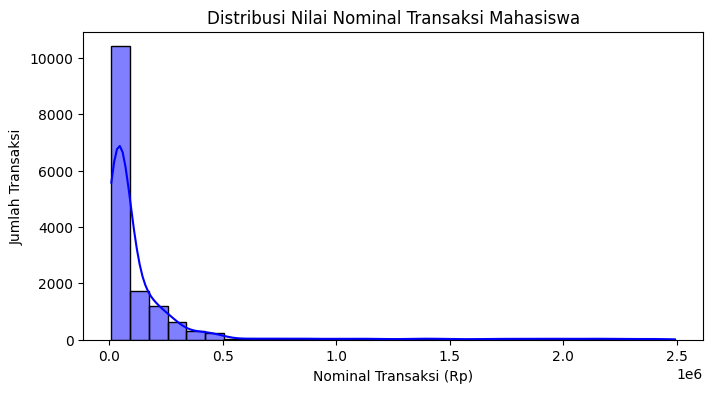

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df['amount'], kde=True, color='blue', bins=30)
plt.title('Distribusi Nilai Nominal Transaksi Mahasiswa')
plt.xlabel('Nominal Transaksi (Rp)')
plt.ylabel('Jumlah Transaksi')
plt.show() # Visualisasi sebaran nilai nominal transaksi (amount) untuk melihat rentang belanja mahasiswa

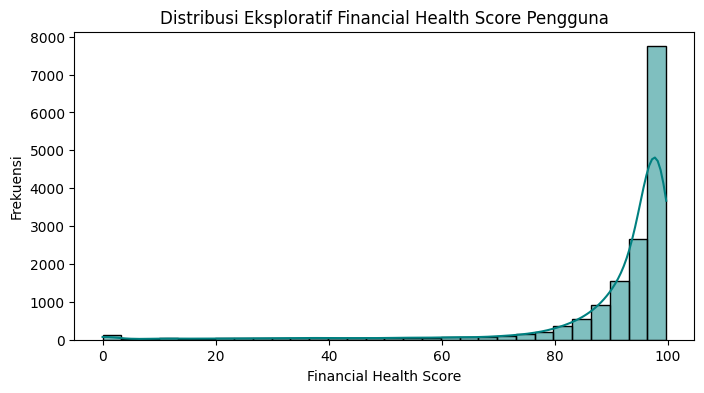

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df['financial_health_score'], kde=True, color='teal', bins=30)
plt.title('Distribusi Eksploratif Financial Health Score Pengguna')
plt.xlabel('Financial Health Score')
plt.ylabel('Frekuensi')
plt.show()

### 1. Deteksi Outlier Variabel Numerik

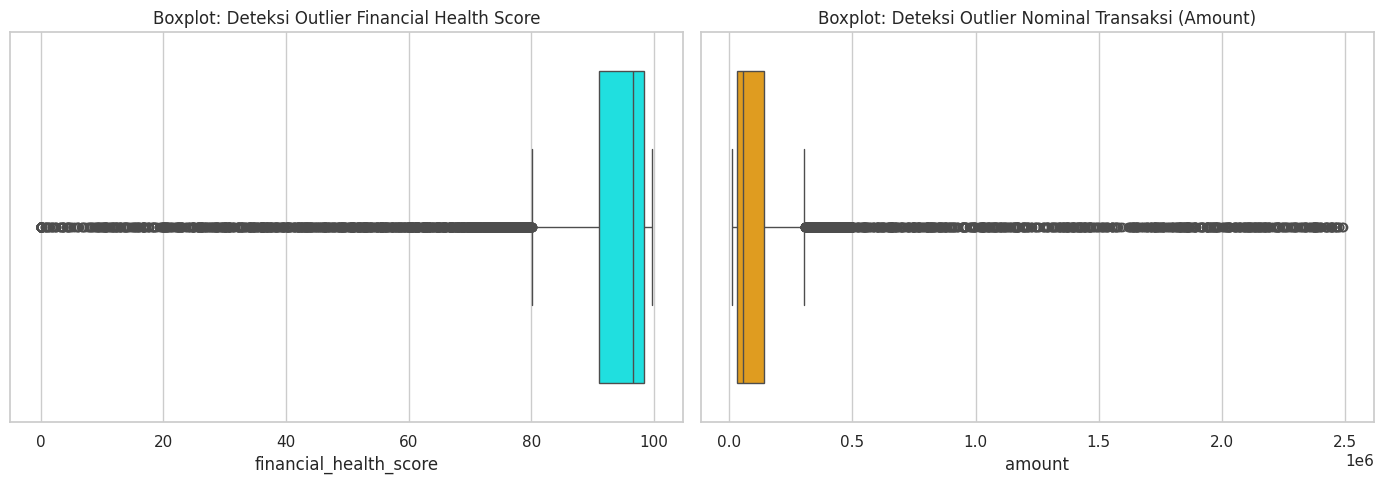

In [ ]:
# Mendeteksi nilai ekstrem (outlier) pada skor finansial dan nominal transaksi
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df['financial_health_score'], ax=ax[0], color='cyan')
ax[0].set_title('Boxplot: Deteksi Outlier Financial Health Score')

sns.boxplot(x=df['amount'], ax=ax[1], color='orange')
ax[1].set_title('Boxplot: Deteksi Outlier Nominal Transaksi (Amount)')

plt.tight_layout()
plt.show()

### 2. Proporsi Data Kategorikal

Tabel Frekuensi Penggunaan Metode Pembayaran:
payment_method
Credit Card      5101
Bank Transfer    5097
E-Wallet         5041
Name: count, dtype: int64


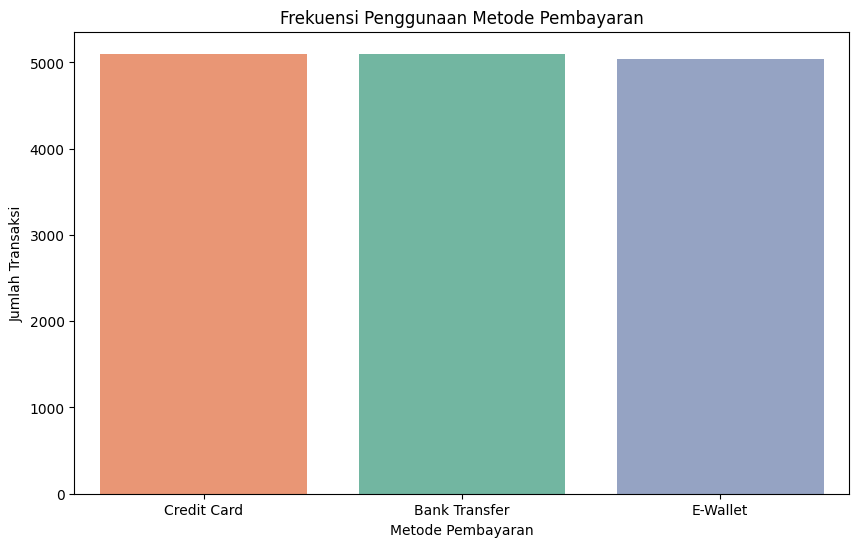

In [ ]:
print("Tabel Frekuensi Penggunaan Metode Pembayaran:")
print(df['payment_method'].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(x='payment_method', data=df, order=df['payment_method'].value_counts().index, palette='Set2', hue='payment_method', legend=False)
plt.title('Frekuensi Penggunaan Metode Pembayaran')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Jumlah Transaksi')
plt.show()

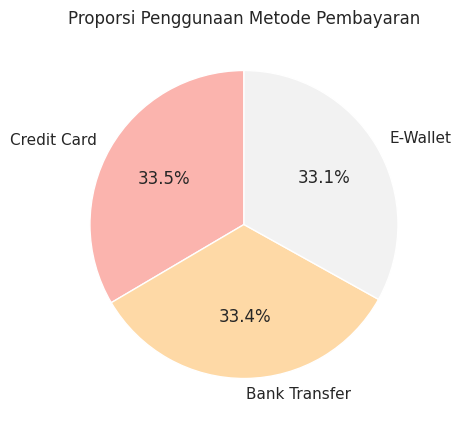

In [ ]:
plt.figure(figsize=(8, 5))
df['payment_method'].value_counts().plot.pie(autopct='%1.1f%%', cmap='Pastel1', startangle=90)
plt.title('Proporsi Penggunaan Metode Pembayaran')
plt.ylabel('')
plt.show()

## B. EDA: Analisis Multivariat (Eksplorasi Hubungan Antar Kolom)
Sekorang akan melihat interaksi langsung antara variabel-variabel numerik untuk melihat apakah ada korelasi atau ketergantungan antar nilai kolom.

### 1. Hubungan & Korelasi Antar Variabel Numerik

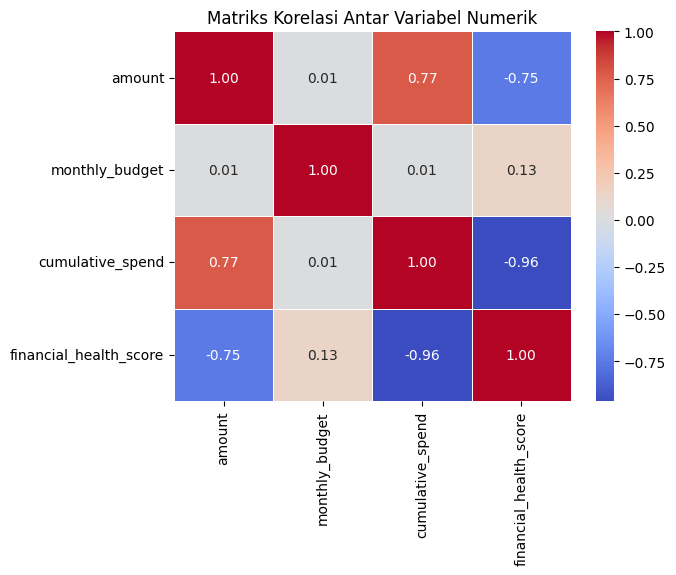

In [ ]:
matriks_korelasi = df[['amount', 'monthly_budget', 'cumulative_spend', 'financial_health_score']].corr() #Menghitung matriks korelasi antar fitur numerik

sns.heatmap(matriks_korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Antar Variabel Numerik')
plt.show()

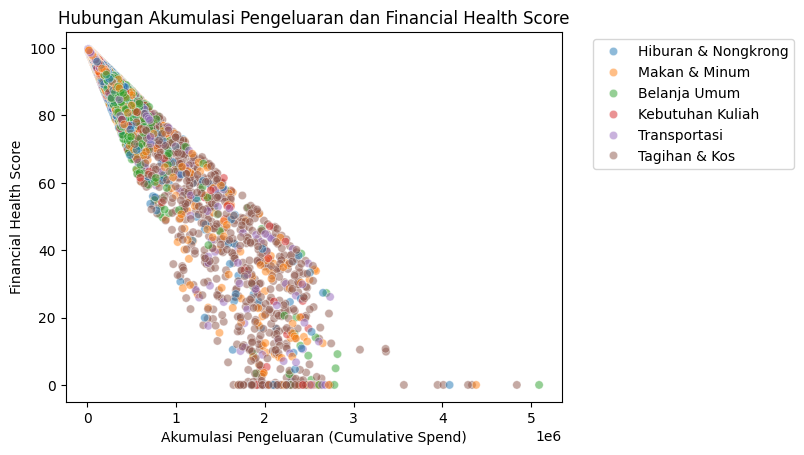

In [ ]:
sns.scatterplot(x='cumulative_spend', y='financial_health_score', data=df, alpha=0.5, hue='category')
plt.title('Hubungan Akumulasi Pengeluaran dan Financial Health Score') #Melihat pergerakan akumulatif belanja mahasiswa terhadap kestabilan skor kesehatan keuangannya
plt.xlabel('Akumulasi Pengeluaran (Cumulative Spend)')
plt.ylabel('Financial Health Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### 2. Pengaruh Variabel Kategorikal terhadap Target

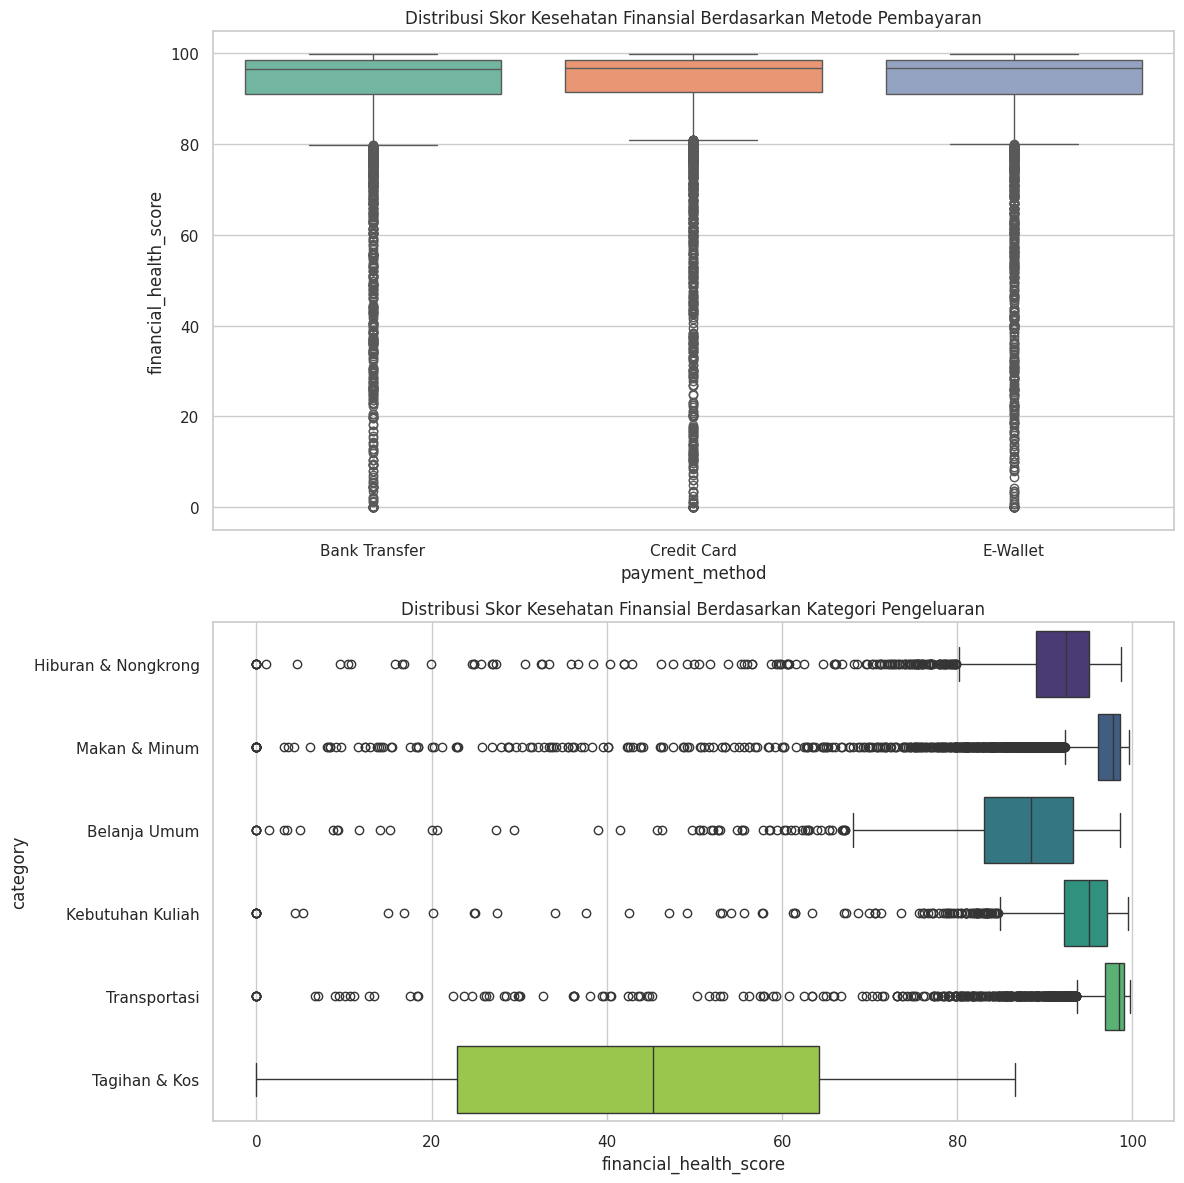

In [ ]:
# Melihat apakah metode pembayaran atau kategori tertentu memiliki skor finansial yang lebih rentan
fig, ax = plt.subplots(2, 1, figsize=(12, 12))

sns.boxplot(data=df, x='payment_method', y='financial_health_score', palette='Set2', ax=ax[0], hue='payment_method', legend=False)
ax[0].set_title('Distribusi Skor Kesehatan Finansial Berdasarkan Metode Pembayaran')

sns.boxplot(data=df, y='category', x='financial_health_score', palette='viridis', ax=ax[1], hue='category', legend=False)
ax[1].set_title('Distribusi Skor Kesehatan Finansial Berdasarkan Kategori Pengeluaran')

plt.tight_layout()
plt.show()

## C. Analisis Proporsi Anggaran

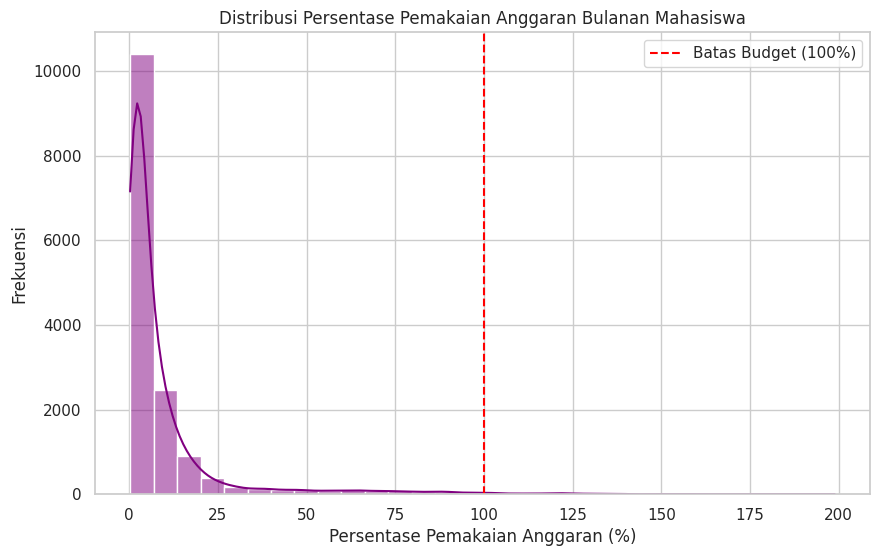

In [ ]:
# Membuat rasio untuk melihat seberapa besar mahasiswa menghabiskan budget bulanannya
df['budget_usage_ratio'] = (df['cumulative_spend'] / df['monthly_budget']) * 100

plt.figure(figsize=(10, 6))
sns.histplot(df['budget_usage_ratio'], kde=True, color='purple', bins=30)
plt.axvline(100, color='red', linestyle='--', label='Batas Budget (100%)')
plt.title('Distribusi Persentase Pemakaian Anggaran Bulanan Mahasiswa')
plt.xlabel('Persentase Pemakaian Anggaran (%)')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

## D. Analisis Runtun Waktu (Time-Series)

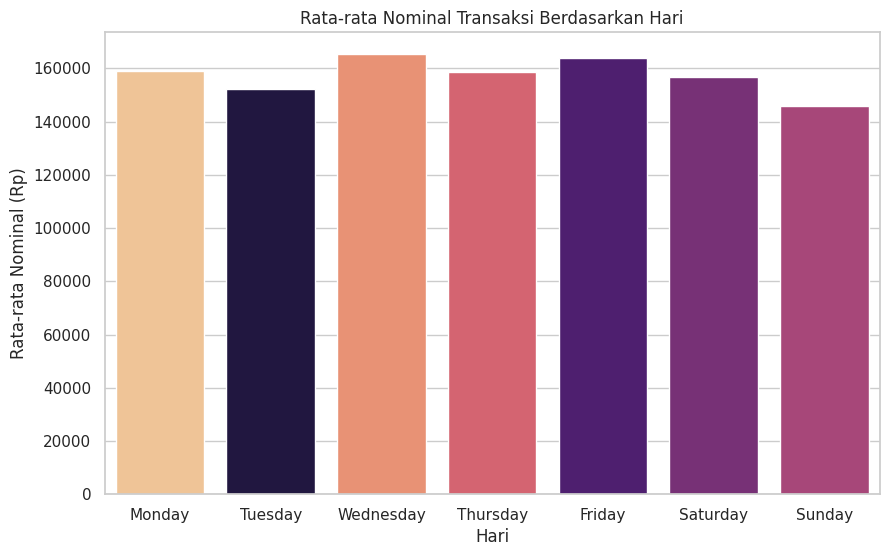

In [ ]:
# Mengekstrak nama hari dan bulan dari kolom date
df['day_of_week'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month_name()

# Urutan hari untuk visualisasi
hari_urut = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='day_of_week', y='amount', order=hari_urut, estimator='mean', errorbar=None, palette='magma', hue='day_of_week', legend=False)
plt.title('Rata-rata Nominal Transaksi Berdasarkan Hari')
plt.xlabel('Hari')
plt.ylabel('Rata-rata Nominal (Rp)')
plt.show()

## E. Kesimpulan Akhir EDA & Rekomendasi

Berdasarkan hasil Exploratory Data Analysis (EDA) pada dataset Finesse, ditarik kesimpulan berikut:

1. **Distribusi & Outlier:** Mayoritas metrik terpusat, namun terdapat *outlier* pada nominal transaksi yang perlu ditangani agar tidak membiaskan model.
2. **Pola Kategorikal:** Metode pembayaran dan kategori pengeluaran terbukti memiliki korelasi langsung terhadap tinggi-rendahnya skor kesehatan finansial.
3. **Serapan Anggaran:** Rasio pengeluaran kumulatif terhadap anggaran bulanan merupakan indikator terkuat untuk kedisiplinan finansial pengguna.
4. **Tren Waktu:** Terdapat fluktuasi transaksi berdasarkan hari yang menunjukkan pola konsumsi dinamis.